*My local laptop doesn't have enough CPU and GPU so I used Google colab for this*

https://colab.research.google.com/drive/1a3-y3l53rq92f5spDUAnsmgRc_0BuKeY#scrollTo=2zc9LoTwHE-o

In [3]:
import os, numpy as np, tensorflow as tf
from datetime import datetime
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.applications import efficientnet
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Runs part of training in float16 (half-precision) to make it faster on GPUs
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

from google.colab import drive
drive.mount('/content/drive', force_remount=True)
DATASET_ROOT = f"/content/drive/MyDrive/notebooks/image_classification/animals_plants_dataset"
DATA_DIR = os.path.join(DATASET_ROOT, "train")
if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(f"DATA_DIR not found: {DATA_DIR}")

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

IMG_SIZE = (224, 224) # standard for CNNs & EfficientNet
BATCH = 64
AUTOTUNE = tf.data.AUTOTUNE # lets TensorFlow optimize pipeline performance automatically

Mounted at /content/drive


In [4]:
# Load and Split the Dataset

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH)

temp_val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=False)

temp_card = tf.data.experimental.cardinality(temp_val_ds).numpy()
val_batches = temp_card // 2
val_ds = temp_val_ds.take(val_batches)
test_ds = temp_val_ds.skip(val_batches)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Class names: {class_names}")
print(f"Number of classes: {num_classes}")

Found 10008 files belonging to 10 classes.
Using 8007 files for training.
Found 10008 files belonging to 10 classes.
Using 2001 files for validation.
Class names: ['Amphibia', 'Animalia', 'Arachnida', 'Aves', 'Fungi', 'Insecta', 'Mammalia', 'Mollusca', 'Plantae', 'Reptilia']
Number of classes: 10


In [5]:
# Data Augmentation and Preprocessing

augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
], name="augment")

# A. EfficientNet pipeline
# use efficientnet.preprocess_input(x) (scales pixels between -1 and 1)
train_eff = train_ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_eff = train_eff.map(lambda x, y: (efficientnet.preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
val_eff   = val_ds.map(lambda x, y: (efficientnet.preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
test_eff  = test_ds.map(lambda x, y: (efficientnet.preprocess_input(x), y), num_parallel_calls=AUTOTUNE)

# B. Scratch CNN pipeline
# rescale pixel values from [0,255] → [0,1]
rescale = tf.keras.layers.Rescaling(1./255)
train_scratch = train_ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_scratch = train_scratch.map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE)
val_scratch   = val_ds.map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE)
test_scratch  = test_ds.map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE)

# speed up the pipeline by keeping images in memory and overlapping preprocessing with GPU work
train_eff = train_eff.cache().prefetch(AUTOTUNE)
val_eff   = val_eff.cache().prefetch(AUTOTUNE)
test_eff  = test_eff.cache().prefetch(AUTOTUNE)

train_scratch = train_scratch.cache().prefetch(AUTOTUNE)
val_scratch   = val_scratch.cache().prefetch(AUTOTUNE)
test_scratch  = test_scratch.cache().prefetch(AUTOTUNE)

In [6]:
# Callbacks
# Helper functions to protect me from overfitting and losing the best model since I'm running on a free version of Goolge Collab

# Early stopping
# stops training if validation accuracy doesn’t improve for 5 epochs
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

# ModelCheckpoint
# saves the best model during training by validation metric
ckpt_scratch = ModelCheckpoint(
    filepath="best_scratch.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

ckpt_transfer = ModelCheckpoint(
    filepath="best_transfer.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

ckpt_finetune = ModelCheckpoint(
    filepath="best_transfer_finetuned.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [7]:
# Model 1: CNN From Scratch
# https://www.tensorflow.org/tutorials/images/cnn
# https://learnopencv.com/implementing-cnn-tensorflow-keras/

# A CNN automatically learns hierarchical features:
# - First layers: edges and textures
# - Middle layers: shapes and object parts
# - Last layers: class patterns

def build_scratch_cnn(input_shape, num_classes, dropout):
    inputs = layers.Input(shape=input_shape)
    x = inputs
    x = layers.Conv2D(32, 3, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(64, 3, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(128, 3, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
    model = models.Model(inputs, outputs, name="scratch_cnn")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                  metrics=['accuracy'])
    return model

scratch_model = build_scratch_cnn(
    input_shape=IMG_SIZE+(3,),
    num_classes=num_classes,
    dropout=0.3) # randomly deactivates 30% neurons to prevent overfitting

scratch_model.summary()

Model: "scratch_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,434 (372.79 KB)

 Trainable params: 94,986 (371.04 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1841 - loss: 2.4112
Epoch 1: val_accuracy improved from -inf to 0.00000, saving model to best_scratch.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.1842 - loss: 2.4103 - val_accuracy: 0.0000e+00 - val_loss: 2.5618
Epoch 2/20
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.2198 - loss: 2.1839
Epoch 2: val_accuracy did not improve from 0.00000
126/126 ━━━━━━━━━━━━━━━━━━━━ 66s 62ms/step - accuracy: 0.2199 - loss: 2.1838 - val_accuracy: 0.0000e+00 - val_loss: 2.9494
Epoch 3/20
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.2456 - loss: 2.1418
Epoch 3: val_accuracy improved from 0.00000 to 0.01855, saving model to best_scratch.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.2456 - loss: 2.1416 - val_accuracy: 0.0186 - val_loss: 2.8014
Epoch 4/20
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.2693 - loss: 2.0875
Epoch 4: val_accuracy improved from 0.01855 to 0.13477, savin

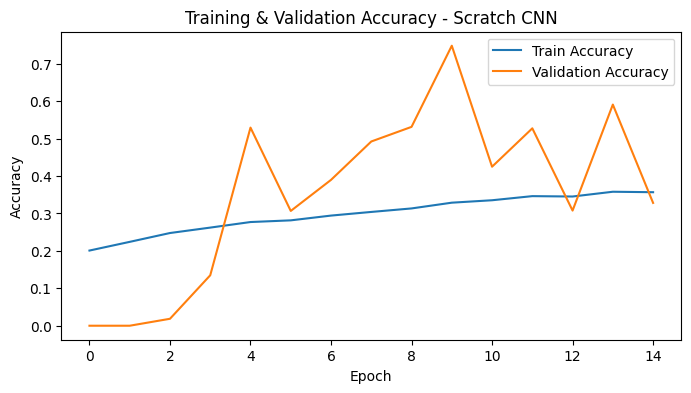

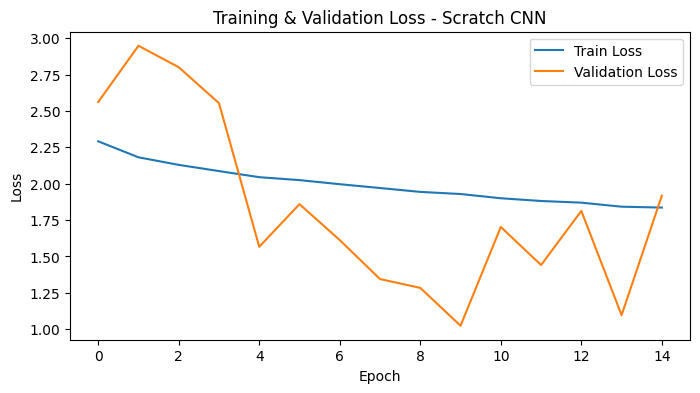

In [8]:
# plot curves to visualize how the model learned over time

history_scratch = scratch_model.fit(
    train_scratch,
    validation_data=val_scratch,
    epochs=20,
    callbacks=[early_stop, ckpt_scratch])

# Plot accuracy
plt.figure(figsize=(8,4))
plt.plot(history_scratch.history['accuracy'], label='Train Accuracy')
plt.plot(history_scratch.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy - Scratch CNN')
plt.show()

# Plot loss
plt.figure(figsize=(8,4))
plt.plot(history_scratch.history['loss'], label='Train Loss')
plt.plot(history_scratch.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss - Scratch CNN')
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


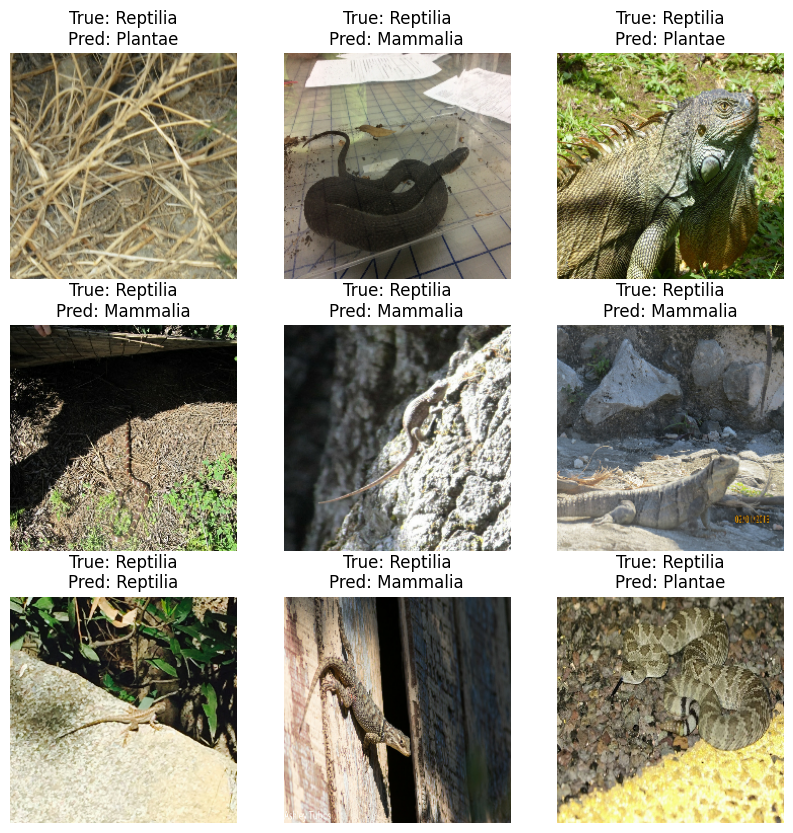

In [9]:
for images, labels in test_scratch.take(1):
    preds = scratch_model.predict(images)
    plt.figure(figsize=(10,10))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow((images[i].numpy()*255).astype("uint8"))
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[np.argmax(preds[i])]}")
        plt.axis("off")

In [10]:
# Model 2: Transfer Learning (EfficientNetB0)
# https://keras.io/api/applications/efficientnet/
# https://www.tensorflow.org/tutorials/images/transfer_learning

# EfficientNetB0 is a pretrained CNN that has already learned from 1.2M images on ImageNet
# Leveraged on this, I reused its feature extractor and only train the last few layers for my dataset

base = tf.keras.applications.EfficientNetB0(include_top=False, weights="imagenet", input_shape=IMG_SIZE+(3,))
base.trainable = False # removes the ImageNet classifier head


inputs = layers.Input(shape=IMG_SIZE+(3,))
x = base(inputs, training=False)

# use my own classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
transfer_model = tf.keras.Model(inputs, outputs)

transfer_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                       loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                       metrics=['accuracy'])

# Fine-tuning

# unfreeze part of EfficientNet to let it adapt to the dataset
base.trainable = True
for layer in base.layers[:-20]:
    layer.trainable = False

# last 20 layers are retrained with a smaller learning rate (1e-4
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

transfer_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 1,363,770 (5.20 MB)

 Non-trainable params: 2,698,611 (10.29 MB)

Epoch 1/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3725 - loss: 1.8969
Epoch 1: val_accuracy improved from -inf to 0.68555, saving model to best_transfer_finetuned.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 286s 2s/step - accuracy: 0.3737 - loss: 1.8941 - val_accuracy: 0.6855 - val_loss: 1.1931
Epoch 2/20
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7127 - loss: 0.9274
Epoch 2: val_accuracy improved from 0.68555 to 0.74707, saving model to best_transfer_finetuned.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.7128 - loss: 0.9268 - val_accuracy: 0.7471 - val_loss: 0.9324
Epoch 3/20
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7673 - loss: 0.7334
Epoch 3: val_accuracy improved from 0.74707 to 0.76562, saving model to best_transfer_finetuned.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.7673 - loss: 0.7332 - val_accuracy: 0.7656 - val_loss: 0.8309
Epoch 4/20
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7994 - loss: 0.62

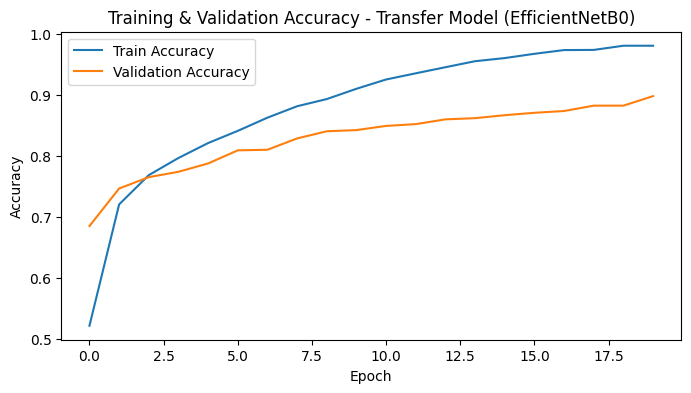

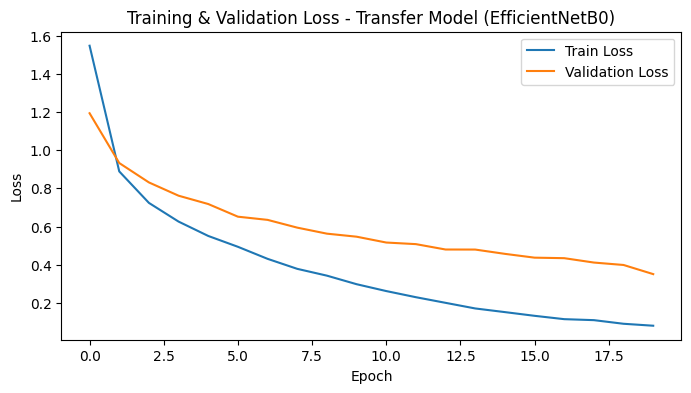

In [11]:
# plot curves to visualize how the model learned over time
history_transfer = transfer_model.fit(
    train_eff,
    validation_data=val_eff,
    epochs=20,
    callbacks=[early_stop, ckpt_finetune])

# Plot accuracy
plt.figure(figsize=(8,4))
plt.plot(history_transfer.history['accuracy'], label='Train Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy - Transfer Model (EfficientNetB0)')
plt.show()

# Plot loss
plt.figure(figsize=(8,4))
plt.plot(history_transfer.history['loss'], label='Train Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss - Transfer Model (EfficientNetB0)')
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 41s 68ms/step


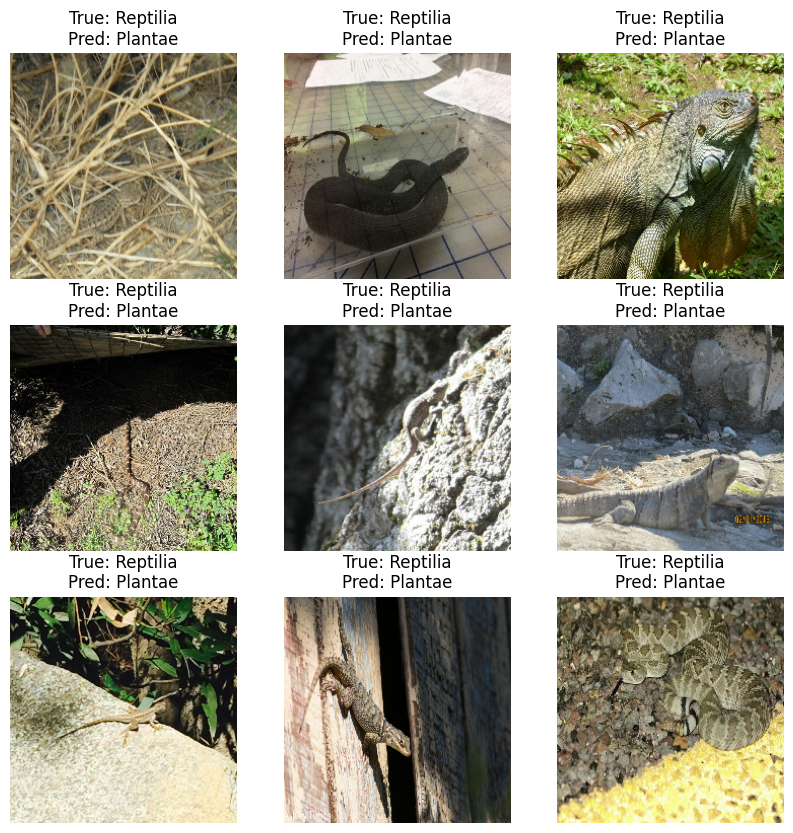

In [12]:
for images, labels in test_scratch.take(1):
    preds = transfer_model.predict(images)
    plt.figure(figsize=(10,10))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow((images[i].numpy()*255).astype("uint8"))
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[np.argmax(preds[i])]}")
        plt.axis("off")

In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def evaluate_and_plot(model, ds, num_classes, class_names, model_name="model"):
    # Collect true labels (one pass)
    y_true = np.concatenate([labels.numpy() for _, labels in ds], axis=0)

    # Predict once over the whole dataset
    preds = model.predict(ds, verbose=0)
    y_pred = np.argmax(preds, axis=1)

    # Top-1 accuracy
    top1_acc = np.mean(y_pred == y_true)
    print(f"{model_name} Top-1 Accuracy: {top1_acc:.4f}")

    # Macro accuracy (avg of per-class accuracies)
    class_accuracies = []
    for c in range(num_classes):
        idx = (y_true == c)
        acc = np.mean(y_pred[idx] == y_true[idx]) if np.sum(idx) > 0 else np.nan
        class_accuracies.append(acc)
    macro_acc = np.nanmean(class_accuracies)
    print(f"{model_name} Macro Accuracy: {macro_acc:.4f}")

    # Confusion Matrix (plotted in #10 with labels)
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))

evaluate_and_plot(scratch_model, test_scratch, num_classes, class_names, "Scratch CNN")
evaluate_and_plot(transfer_model, test_eff, num_classes, class_names, "EfficientNetB0 (Frozen)")
evaluate_and_plot(transfer_model, test_eff, num_classes, class_names, "EfficientNetB0 (Fine-tuned)")


Scratch CNN Top-1 Accuracy: 0.3818
Scratch CNN Macro Accuracy: 0.3818
EfficientNetB0 (Frozen) Top-1 Accuracy: 0.9396
EfficientNetB0 (Frozen) Macro Accuracy: 0.9396
EfficientNetB0 (Fine-tuned) Top-1 Accuracy: 0.9396
EfficientNetB0 (Fine-tuned) Macro Accuracy: 0.9396
